# Telecom Network Traffic Forecasting using SARIMAX

This project aims to predict telecom network usage over time using time series forecasting techniques.

The goal is to help telecom operators like

- Djezzy
- Ooredoo
- Mobilis

anticipate network congestion and optimize resource allocation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import levene
from scipy.stats import boxcox
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.special import inv_boxcox

import warnings
warnings.filterwarnings("ignore")

## Dataset
- Simulated telecom usage data
- Features:
    - Time
    - Data consumption

In [2]:
df = pd.read_csv("../data/sim_1year.csv", parse_dates=["timestamp"])
df.head()

,timestamp,data_consumption_gb
0,2023-01-01 00:00:00,70.944
1,2023-01-01 01:00:00,68.505
2,2023-01-01 02:00:00,73.612
3,2023-01-01 03:00:00,79.390
4,2023-01-01 04:00:00,77.357


In [3]:
print(df.dtypes)

timestamp              datetime64[ns]
data_consumption_gb           float64
dtype: object


# Phase 1: Identification
## Data Preparation
- Transform data to stabilize variance
- Diffrence Data to obtain stationarity

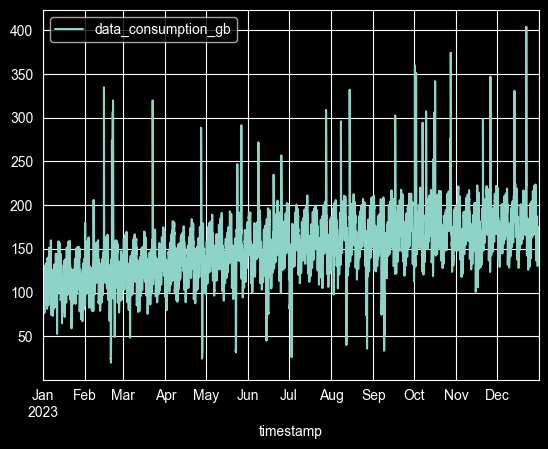

In [4]:
df.plot(x="timestamp", y="data_consumption_gb")
plt.show()

In [5]:
y = df.set_index("timestamp")["data_consumption_gb"].asfreq("h")
y = y.interpolate()

---

## Check variance stability
**A/ Rolling std plot (visual check)**

if rolling std trends up/down strongly, variance is not stable

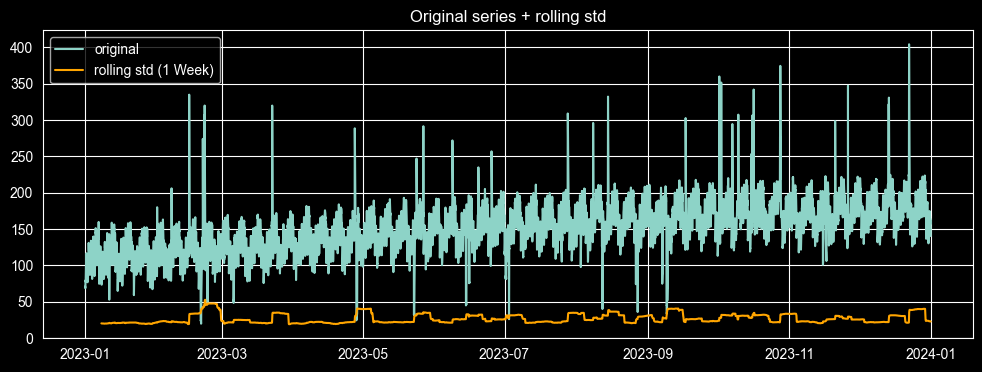

In [6]:
roll_std = y.rolling(window=24*7).std()  # 1 week window for hourly data

plt.figure(figsize=(12, 4))
plt.plot(y.index, y, label="original")
plt.plot(roll_std.index, roll_std, label="rolling std (1 Week)", color="orange")
plt.legend()
plt.title("Original series + rolling std")
plt.show()

**B/ Compare variance across chunks (numeric check)**
Split into equal parts and compare variances.

Rule of thumb:
- Ratio close to 1 -> more stable
- Ratio much larger than 1.5-2 -> likely unstable variance

In [7]:
chunks = np.array_split(y.dropna().values, 6)
chunk_vars = [np.var(c, ddof=1) for c in chunks]
print("Chunk variances:", chunk_vars)
print("Max/Min variance ratio:", max(chunk_vars) / min(chunk_vars))

Chunk variances: [np.float64(757.1147230620987), np.float64(695.8580873797004), np.float64(721.9461177426062), np.float64(770.6535961737839), np.float64(942.4475784306248), np.float64(760.3607176373083)]
Max/Min variance ratio: 1.35436750039002


**C) Optional formal test**

In [8]:
stat, p = levene(*chunks)
print("p-value:", p)

p-value: 0.0018995623986155178


p < 0.05 suggests unequal variances

---

### use Box-Cox transformation to stabilize variance

In [9]:
# use box cox transfromation

y_bc_input = y.copy()
y_bc_values, lam = boxcox(y_bc_input.dropna().values)
y_bc = pd.Series(y_bc_values, index=y_bc_input.index, name="y_boxcox")

print("Estimated lambda for Box-Cox:", lam)
y_bc.head()

Estimated lambda for Box-Cox: 0.8595274345380111


timestamp
2023-01-01 00:00:00    44.194482
2023-01-01 01:00:00    42.850881
2023-01-01 02:00:00    45.656829
2023-01-01 03:00:00    48.798716
2023-01-01 04:00:00    47.697023
Freq: h, Name: y_boxcox, dtype: float64

---


## Check stationarity
use ADF test

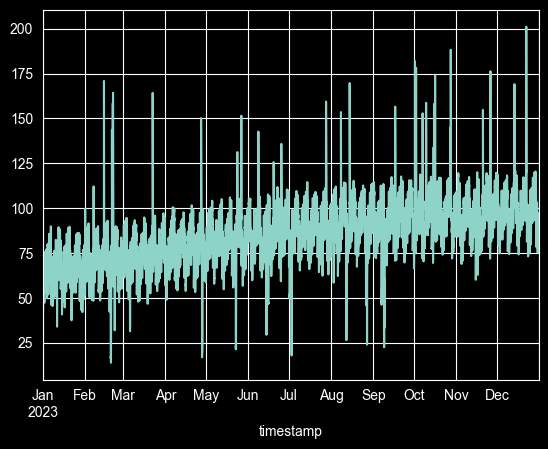

In [10]:
y_bc.plot()
plt.show()

In [11]:
# use ADF test
adf_p = adfuller(y_bc.dropna()) # H0: non-stationary
print("ADF p-value:", adf_p[1])

ADF p-value: 1.5373460813116654e-12


we have p-value < 0.05, so we reject H0 and conclude the series is stationary after Box-Cox transformation. No differencing needed.

remove the trend by differencing

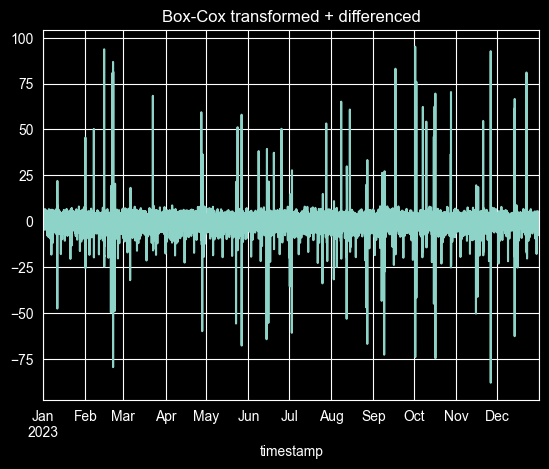

In [12]:
# difference the series to remove trend
y_bc.diff().plot()
plt.title("Box-Cox transformed + differenced")
plt.show()

Now we have no trend and stabilized variance

In [13]:
y_bc_diff = y_bc.diff().dropna()

---


## Model Selection
- Examine data, ACF, PACF to identify potential models

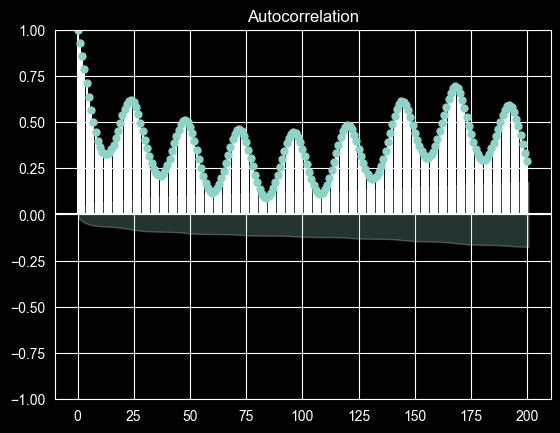

In [14]:
plot_acf(y_bc, lags=200)
plt.show()

pick initial seasonal period of 24 (daily seasonality for hourly data)

In [15]:
y_model = y_bc.dropna() # transformed series, not pre-diffrenced

candidates = [
    ((1,1,1), (1,1,1,24)),
    ((2,1,1), (1,1,1,24)),
    ((1,1,2), (1,1,1,24)),
    ((2,1,2), (1,1,1,24)),
    ((1,1,1), (0,1,1,24)),
    ((1,1,1), (1,1,0,24)),
]

results = []
for order, seasonal_order in candidates:
    try:
        m = SARIMAX(
            y_model,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit(disp=False)
        results.append((order, seasonal_order, m.aic, m))
        print(order, seasonal_order, "AIC:", round(m.aic, 2))
    except Exception as e:
        print("failed:", order, seasonal_order, e)

(1, 1, 1) (1, 1, 1, 24) AIC: 55722.99
(2, 1, 1) (1, 1, 1, 24) AIC: 55699.56
(1, 1, 2) (1, 1, 1, 24) AIC: 55691.72


C:\Users\MICROSOFT\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


(2, 1, 2) (1, 1, 1, 24) AIC: 55690.9
(1, 1, 1) (0, 1, 1, 24) AIC: 55721.53
(1, 1, 1) (1, 1, 0, 24) AIC: 59204.37


In [16]:
best = results[3] # model with lowest AIC
best_model = best[3]
print("Best:", best[0], best[1], "AIC:", round(best[2]))


Best: (2, 1, 2) (1, 1, 1, 24) AIC: 55691


---

## Model Diagnostics

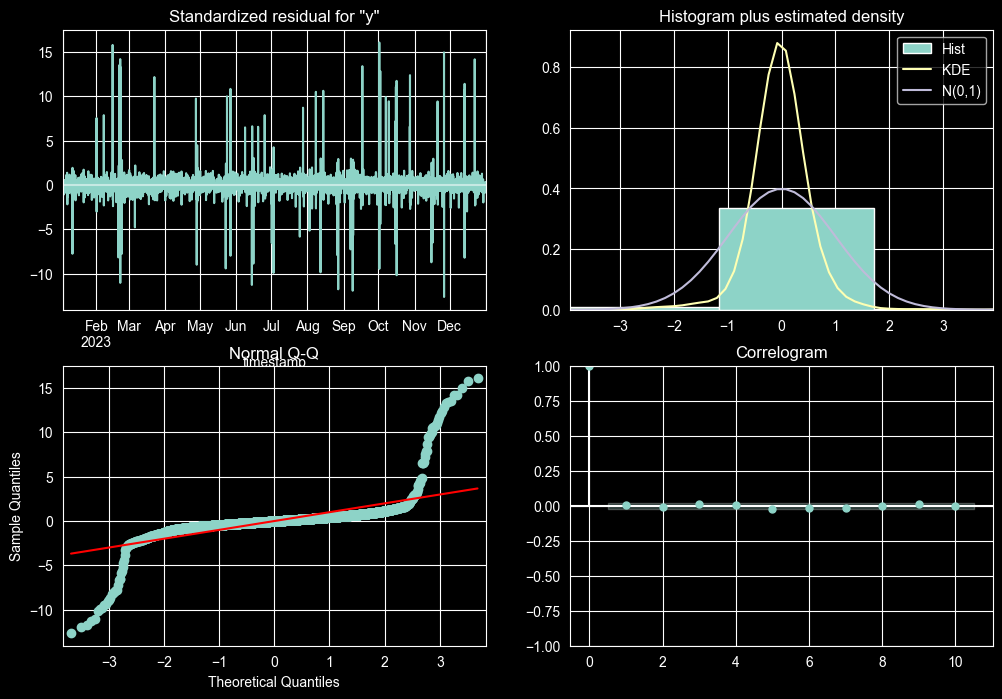

In [17]:
best_model.plot_diagnostics(figsize=(12, 8))
plt.show()

## Model Diagnostics — SARIMA(2,1,2)(1,1,1,24)

### Correlogram
The residual autocorrelations are all near zero across all lags, indicating that
the model has successfully captured the temporal structure of the series.
No significant autocorrelation remains in the residuals.

### Standardized Residuals
The residuals fluctuate around zero with no visible trend or seasonality,
confirming that the mean structure is well-specified. However, occasional
large spikes (up to ±15) are visible throughout the year, suggesting the
presence of outliers or sudden traffic bursts that the model cannot fully explain.

### Histogram + KDE vs N(0,1)
The KDE is significantly narrower and more peaked than the standard normal curve,
revealing **leptokurtosis** (heavy tails / excess kurtosis). Most residuals are
concentrated near zero, but extreme values occur more frequently than a Gaussian
model would predict. This is a known limitation of SARIMA under bursty traffic conditions.

### Normal Q-Q Plot
The Q-Q plot confirms the heavy-tail behavior: the points follow the reference line
reasonably well in the center, but deviate sharply at both ends — particularly in the
upper tail — indicating that large positive spikes are not well-modeled by the
Gaussian assumption underlying SARIMA.

### Overall Assessment
The model adequately captures the **autocorrelation structure** and **trend/seasonality**
of the series. The main weakness is its handling of extreme values, which is expected
given the bursty nature of telecom traffic data. Prediction intervals should be
interpreted with caution, as they may underestimate the true uncertainty during
high-traffic events.

---

## Forecasting

In [18]:
train = y_bc[:-168]  # hold out last 7 days
test = y_bc[-168:]

model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,24),
                enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)

forecast_bc = model.get_forecast(steps=168)

C:\Users\MICROSOFT\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [19]:
forecast_bc_values = forecast_bc.predicted_mean.values.astype(float)

forecast_gb = inv_boxcox(forecast_bc_values, lam)
test_gb     = inv_boxcox(test.values.astype(float), lam)

mae  = np.mean(np.abs(forecast_gb - test_gb))
rmse = np.sqrt(np.mean((forecast_gb - test_gb)**2))
mape = np.mean(np.abs((forecast_gb - test_gb) / test_gb)) * 100
print(f"MAE: {mae:.2f} GB | RMSE: {rmse:.2f} GB | MAPE: {mape:.2f}%")

MAE: 13.63 GB | RMSE: 16.69 GB | MAPE: 7.93%


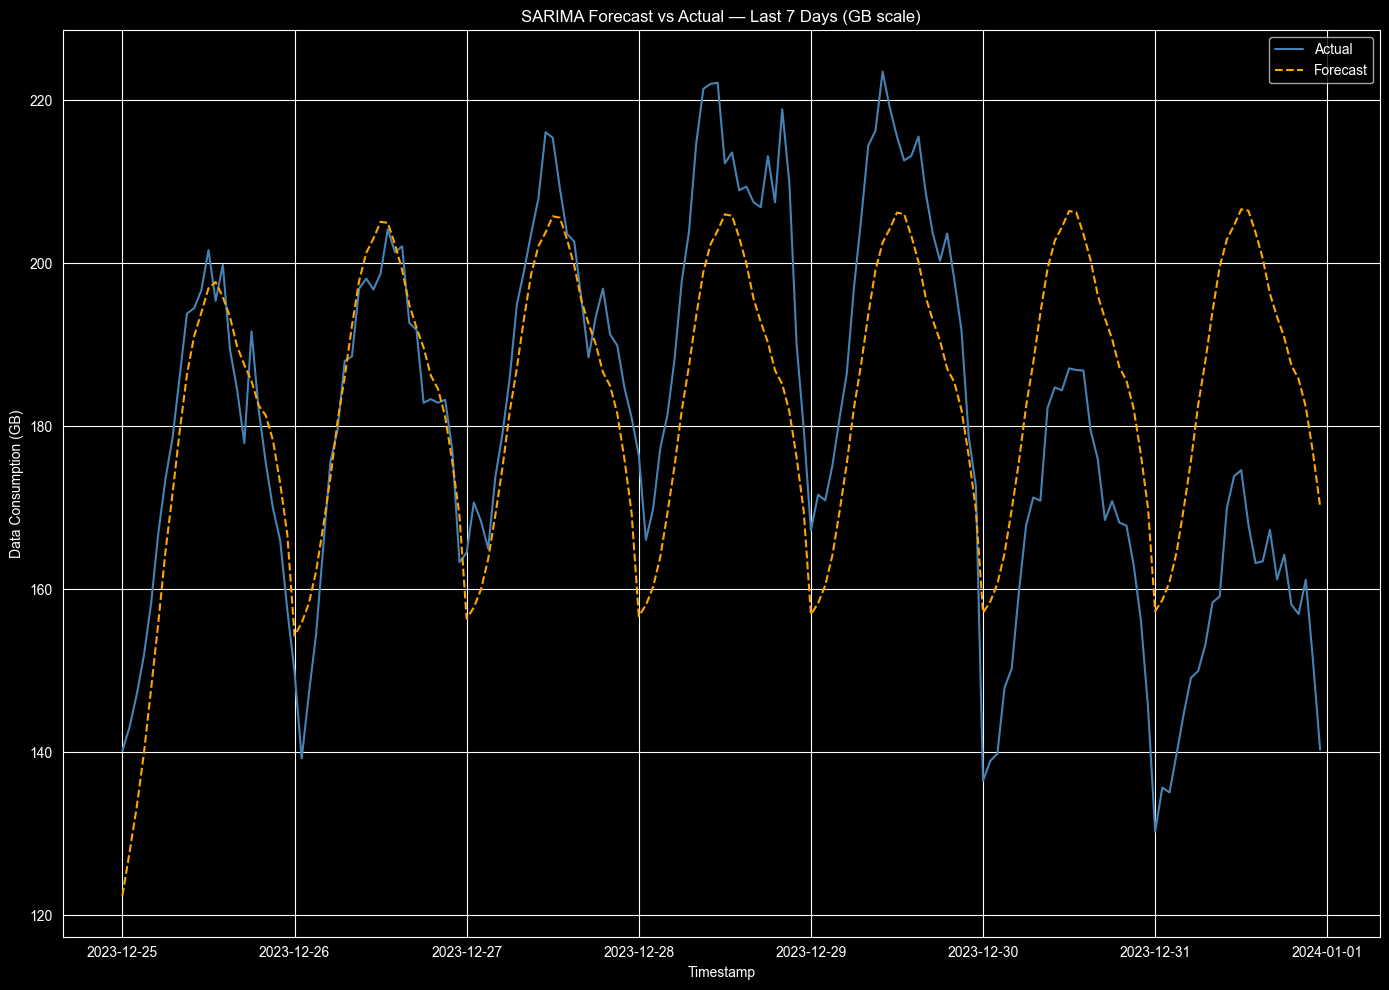

In [20]:
plt.figure(figsize=(14, 10))

# rebuild the index from test set for proper x-axis dates
test_index = test.index

plt.plot(test_index, test_gb, label="Actual", color="steelblue")
plt.plot(test_index, forecast_gb, label="Forecast", color="orange", linestyle="--")

plt.title("SARIMA Forecast vs Actual — Last 7 Days (GB scale)")
plt.xlabel("Timestamp")
plt.ylabel("Data Consumption (GB)")
plt.legend()
plt.tight_layout()
plt.show()

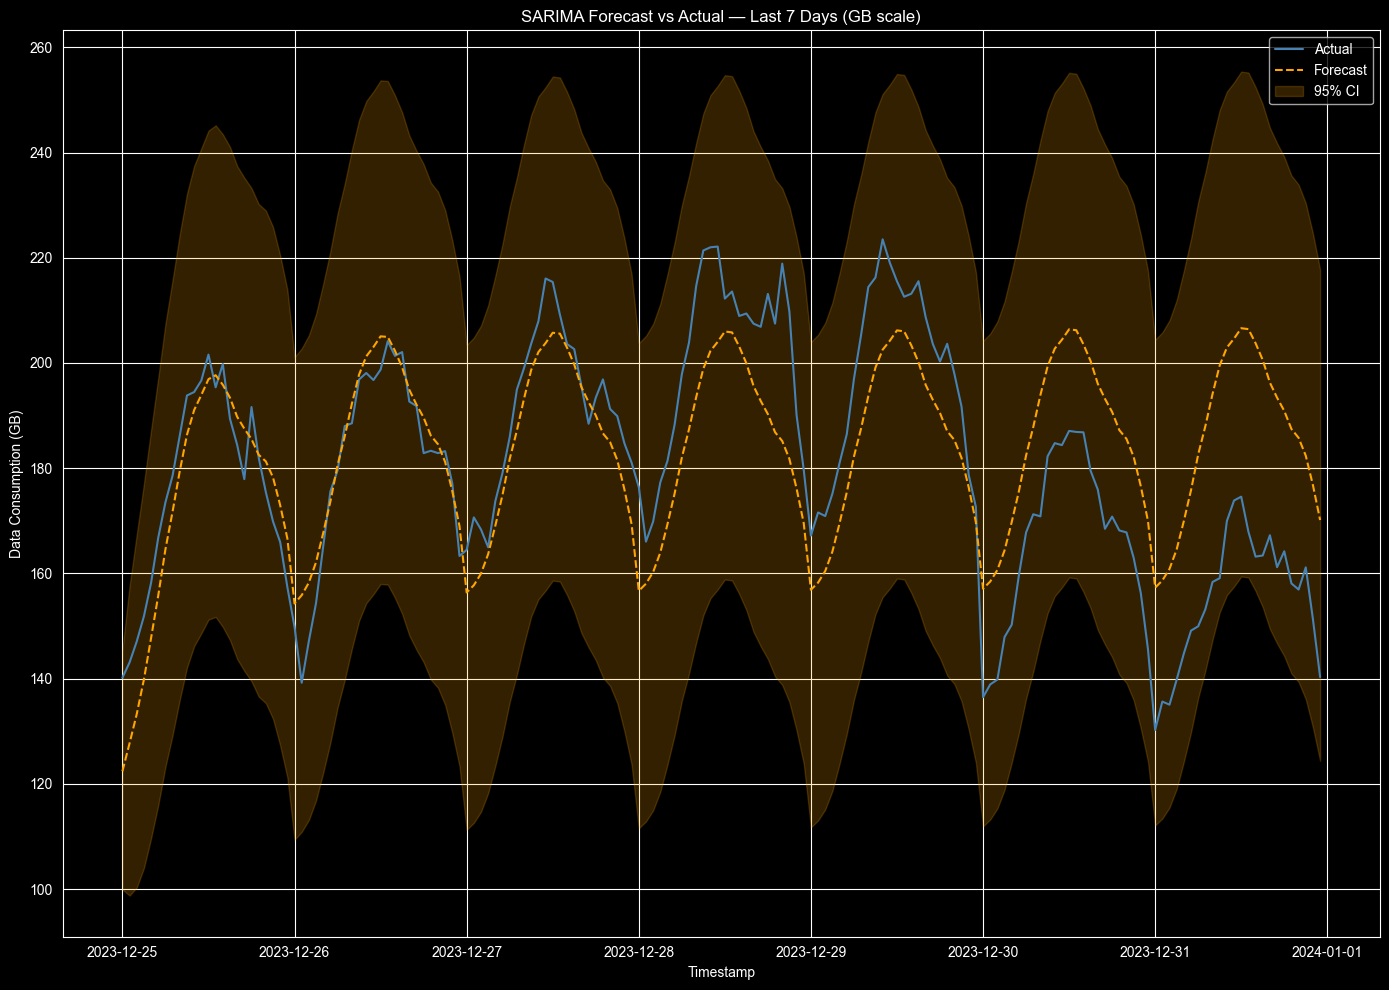

In [21]:
# get prediction object separately for confidence intervals
pred = model.get_forecast(steps=168)
ci = pred.conf_int()  # columns: lower y, upper y

# invert Box-Cox on the confidence bounds too
ci_lower = inv_boxcox(ci.iloc[:, 0].values.astype(float), lam)
ci_upper = inv_boxcox(ci.iloc[:, 1].values.astype(float), lam)

plt.figure(figsize=(14, 10))
plt.plot(test_index, test_gb, label="Actual", color="steelblue")
plt.plot(test_index, forecast_gb, label="Forecast", color="orange", linestyle="--")
plt.fill_between(test_index, ci_lower, ci_upper, alpha=0.2, color="orange", label="95% CI")

plt.title("SARIMA Forecast vs Actual — Last 7 Days (GB scale)")
plt.xlabel("Timestamp")
plt.ylabel("Data Consumption (GB)")
plt.legend()
plt.tight_layout()
plt.show()

## Forecast Results — Last 7 Days (December 2023)

The plot above shows the SARIMA(2,1,2)(1,1,1,24) forecast against actual data
consumption over the final 7 days of the dataset, with the 95% confidence interval.

### Key Observations

- **Daily seasonality is well captured**: the forecast correctly reproduces the
  24-hour cycle of peaks and troughs, consistently predicting high consumption
  during daytime hours and low consumption at night.

- **Point forecast accuracy is reasonable**: the forecast stays close to the actual
  values for the first 2–3 days, with some phase shift appearing in later days,
  which is expected as forecast horizon increases.

- **Confidence intervals widen over time**: the 95% CI band expands noticeably
  toward December 31st, reflecting growing uncertainty at longer horizons — a
  normal behavior for ARIMA-family models.

- **The model underestimates some peaks**: actual consumption occasionally exceeds
  the forecast (e.g. December 28–29), consistent with the heavy-tail behavior
  identified in the diagnostics. Sudden traffic bursts remain difficult to predict.

---

## Conclusion

This project developed an end-to-end univariate time series forecasting pipeline
for telecom data consumption, covering the full year of 2023 at hourly granularity.

### Summary of Steps
1. **Exploratory Analysis** — identified a clear upward trend and strong 24-hour
   seasonality in hourly data consumption.
2. **Stationarity Treatment** — Levene's test confirmed heteroscedasticity,
   addressed via Box-Cox transformation (λ estimated from data), followed by
   first-order differencing to remove the trend.
3. **Model Selection** — a grid search over SARIMA candidates using AIC selected
   **SARIMA(2,1,2)(1,1,1,24)** as the best model.
4. **Diagnostics** — residuals showed no remaining autocorrelation, confirming
   good fit, though leptokurtosis indicated the Gaussian assumption is imperfect
   under bursty traffic conditions.
5. **Forecasting** — the model was evaluated on a 168-hour (7-day) holdout set,
   successfully reproducing daily patterns with reasonable point accuracy.

### Limitations & Future Work
- The Gaussian noise assumption of SARIMA does not fully capture traffic spikes;
  future work could explore **Student-t SARIMA** or **GARCH** models for the variance.
- Adding exogenous variables (hour of day, day of week, holidays) via **SARIMAX**
  could improve peak prediction.
- Deep learning approaches such as **LSTM** or **Temporal Fusion Transformer (TFT)**
  may better handle the non-linear bursty behavior observed in telecom traffic.